# Finding Outliers

This is my own practice notebook based on what I learned in the IBM Data Analyst Capstone Project on Coursera.

This notebook practices exploratory data analysis with a focus on identifying and removing compensation outliers.

## 1. Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load and explore the dataset

Load the dataset into a DataFrame, preview the first rows, and check the dataset structure.

In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

# Create the DataFrame
df = pd.read_csv(file_url)

# Display the first few records
display(df.head())

# Examine the structure of the data
df.info()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB


## 3. Plot the distribution of respondents by industry

Count respondents by industry and visualize the distribution with a bar chart.

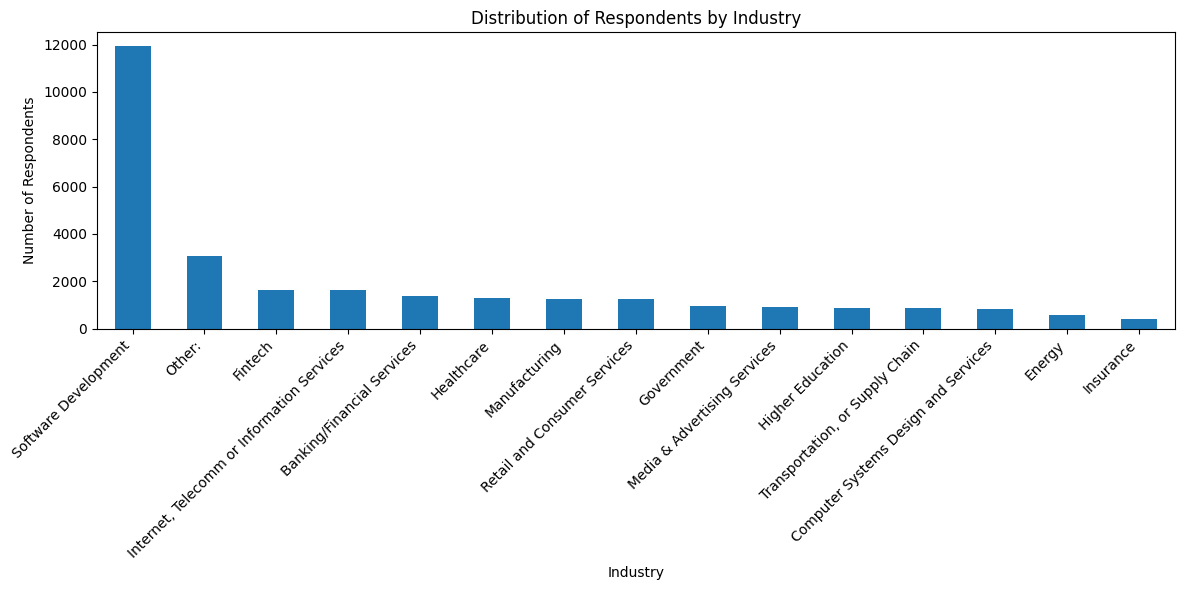

In [3]:
# Count respondents per industry, excluding missing values for this calculation only
industry_counts = df['Industry'].dropna().value_counts()

# Plot the distribution as a bar chart
industry_counts.plot(kind='bar', figsize=(12, 6))

plt.title('Distribution of Respondents by Industry')
plt.xlabel('Industry')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Identify high compensation outliers

Calculate basic statistics and identify very high compensation values using the rule: mean + 3 standard deviations.

In [4]:
# Calculate basic statistics for yearly compensation
mean_comp = df['ConvertedCompYearly'].mean()
median_comp = df['ConvertedCompYearly'].median()
std_comp = df['ConvertedCompYearly'].std()

print("Mean:", mean_comp)
print("Median:", median_comp)
print("Standard Deviation:", std_comp)

# Define the threshold for high compensation outliers
threshold = mean_comp + 3 * std_comp
print("Outlier Threshold:", threshold)

# Find high compensation outliers
high_comp_outliers = df[df['ConvertedCompYearly'] > threshold]
print("Number of High Compensation Outliers:", high_comp_outliers.shape[0])

Mean: 86155.28726264134
Median: 65000.0
Standard Deviation: 186756.97308629757
Outlier Threshold: 646426.2065215341
Number of High Compensation Outliers: 89


## 5. Detect compensation outliers using the IQR method

Calculate Q1, Q3, IQR, lower bound, and upper bound. Then count and visualize outliers using a box plot.

Q1: 32712.0
Q3: 107971.5
IQR: 75259.5
Lower Bound: -80177.25
Upper Bound: 220860.75
Number of Outliers: 978


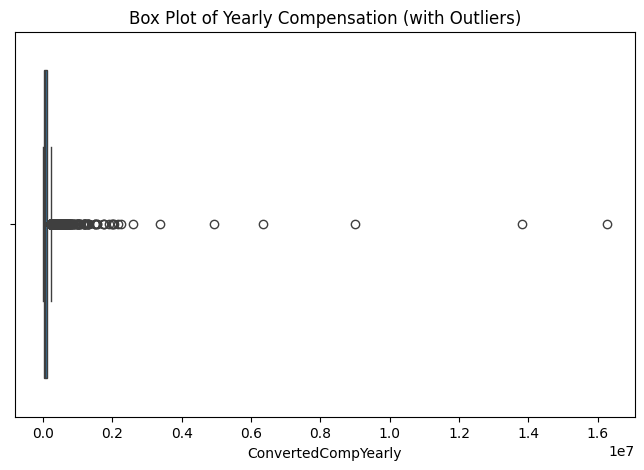

In [5]:
# Calculate Q1 and Q3 for ConvertedCompYearly
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)

# Calculate the Interquartile Range
IQR = Q3 - Q1

# Determine the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers below the lower bound or above the upper bound
outliers = df[
    (df['ConvertedCompYearly'] < lower_bound) |
    (df['ConvertedCompYearly'] > upper_bound)
]

# Display the calculated values
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))

# Visualize outliers using a box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['ConvertedCompYearly'])
plt.title("Box Plot of Yearly Compensation (with Outliers)")
plt.xlabel("ConvertedCompYearly")
plt.show()

## 6. Remove outliers and create a new DataFrame

Create a new DataFrame that removes only the IQR outliers. Rows with missing compensation are kept because missing values are not outliers.

In [6]:
# Remove only outliers and keep rows with missing ConvertedCompYearly
df_no_outliers = df[
    ((df['ConvertedCompYearly'] >= lower_bound) &
     (df['ConvertedCompYearly'] <= upper_bound)) |
    (df['ConvertedCompYearly'].isna())
]

# Validate size
print("Original DataFrame size:", df.shape)
print("New DataFrame size (without outliers):", df_no_outliers.shape)
print("Rows removed:", df.shape[0] - df_no_outliers.shape[0])

Original DataFrame size: (65437, 114)
New DataFrame size (without outliers): (64459, 114)
Rows removed: 978


## 7. Correlation analysis

Convert age groups into approximate numeric values, calculate correlations between numerical columns, and visualize the correlation matrix.

Correlations with AgeNumeric:
AgeNumeric             1.000000
WorkExp                0.848530
ConvertedCompYearly    0.371556
JobSat                 0.067792
CompTotal             -0.002743
JobSatPoints_1        -0.029089
JobSatPoints_8        -0.046238
JobSatPoints_6        -0.049861
JobSatPoints_4        -0.075343
JobSatPoints_9        -0.080869
JobSatPoints_7        -0.081377
JobSatPoints_5        -0.100816
JobSatPoints_11       -0.106338
JobSatPoints_10       -0.112720
Name: AgeNumeric, dtype: float64


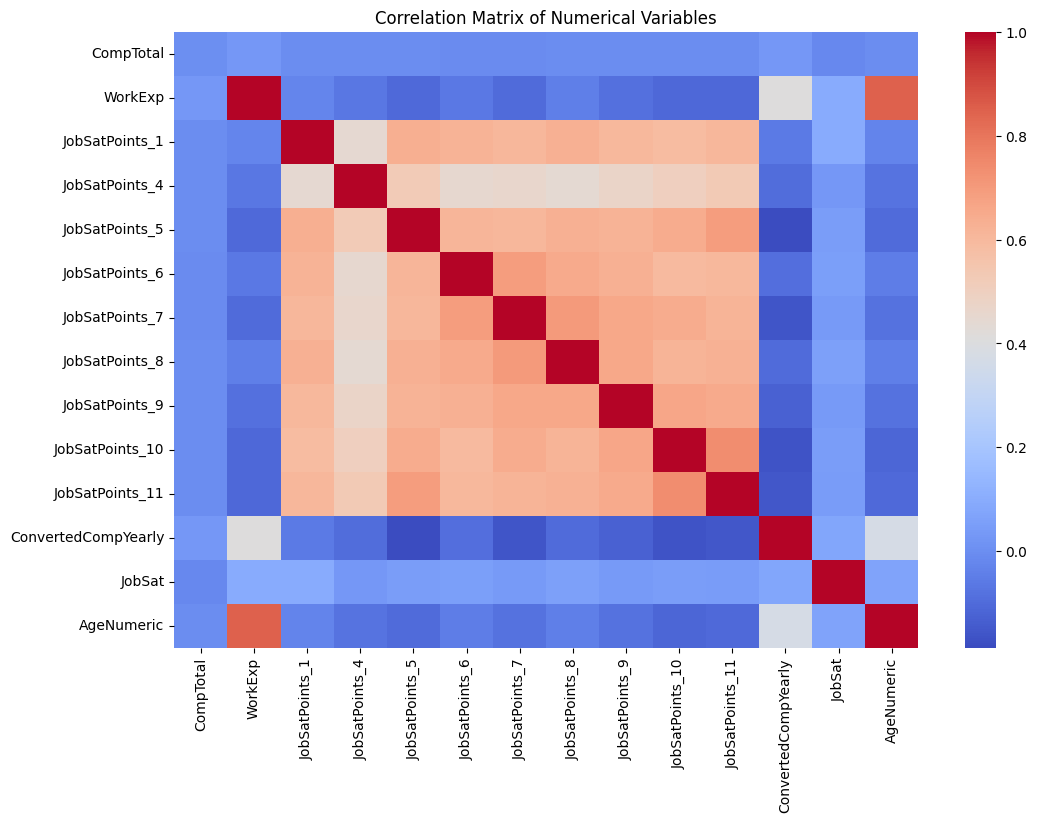

In [7]:
# Create a copy of the DataFrame without outliers
df_corr = df_no_outliers.copy()

# Map Age categories to approximate numeric values
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 65
}

df_corr['AgeNumeric'] = df_corr['Age'].map(age_mapping)

# Select numerical columns
numeric_df = df_corr.select_dtypes(include=['int64', 'float64'])

# Remove ResponseId because it is only an ID, not a meaningful numerical variable
numeric_df = numeric_df.drop(columns=['ResponseId'], errors='ignore')

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Display correlations with AgeNumeric
print("Correlations with AgeNumeric:")
print(correlation_matrix['AgeNumeric'].sort_values(ascending=False))

# Visualize the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

## Summary

This notebook practiced loading and exploring a dataset, plotting industry distribution, detecting compensation outliers using both a statistical threshold and the IQR method, creating a corrected outlier-filtered DataFrame, and performing correlation analysis using a numeric version of age.